In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1. Данные

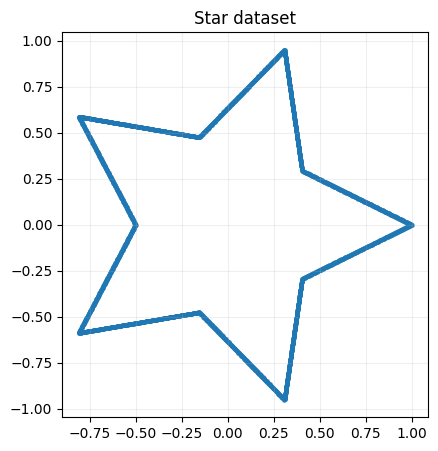

In [14]:
def generate_star(n_spikes=5, inner_radius=0.5, outer_radius=1.0, n_samples=2000, center=(0.0, 0.0)):
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])

    vertices.append(vertices[0])
    vertices = np.asarray(vertices, dtype=np.float32)

    sampled = []
    n_per_edge = max(2, n_samples // (len(vertices) - 1))
    for i in range(len(vertices) - 1):
        p0, p1 = vertices[i], vertices[i + 1]
        for t in np.linspace(0, 1, n_per_edge, endpoint=False):
            sampled.append((1 - t) * p0 + t * p1)

    sampled = np.asarray(sampled[:n_samples], dtype=np.float32)
    return sampled

def plot_star_data(data, title="Star dataset"):
    plt.figure(figsize=(5, 5))
    plt.scatter(data[:, 0], data[:, 1], s=6, alpha=0.7)
    plt.gca().set_aspect("equal", "box")
    plt.grid(alpha=0.2)
    plt.title(title)
    plt.show()

data = generate_star(n_samples=2000)
plot_star_data(data)

## 2. Конфиг и VP-SDE формулы

In [24]:
@dataclass
class Config:
    data_samples: int = 2000
    batch_size: int = 256

    hidden_dim: int = 356
    time_emb_dim: int = 128
    lr: float = 1e-3

    epochs_weight: int = 500
    epochs_schedule: int = 1000

    num_sampling_steps: int = 200

    beta_min: float = 0.1
    beta_max: float = 20.0

    cosine_s: float = 0.008

    clip_grad_norm: float = 1.0

cfg = Config()

def linear_beta(t, cfg):
    return cfg.beta_min + t * (cfg.beta_max - cfg.beta_min)

def cosine_alpha_bar(t, cfg):

    s = cfg.cosine_s
    t = torch.clamp(t, 0.0, 1.0 - 1e-5)
    theta = (t + s) / (1 + s) * math.pi / 2
    theta0 = s / (1 + s) * math.pi / 2
    alpha_bar = (torch.cos(theta) ** 2) / (math.cos(theta0) ** 2)
    return torch.clamp(alpha_bar, min=1e-12, max=1.0)

def vp_marginal_terms(t, cfg, schedule="linear"):
    t = torch.clamp(t, 0.0, 1.0 - 1e-5)

    if schedule == "linear":
        beta_t = linear_beta(t, cfg)
        integral_beta = cfg.beta_min * t + 0.5 * (cfg.beta_max - cfg.beta_min) * t ** 2
        alpha = torch.exp(-0.5 * integral_beta)
        sigma = torch.sqrt(torch.clamp(1.0 - alpha ** 2, min=1e-12))
        return alpha, sigma, beta_t

    if schedule == "cosine":
        alpha_bar = cosine_alpha_bar(t, cfg)
        alpha = torch.sqrt(alpha_bar)
        sigma = torch.sqrt(torch.clamp(1.0 - alpha_bar, min=1e-12))
        theta = (t + cfg.cosine_s) / (1 + cfg.cosine_s) * math.pi / 2
        beta_t = (math.pi / (1 + cfg.cosine_s)) * torch.tan(theta)
        beta_t = torch.clamp(beta_t, max=50.0)
        return alpha, sigma, beta_t

    raise ValueError(f"Unknown schedule: {schedule}")

def time_weight(alpha, sigma, beta, mode="none"):
    eps = 1e-6
    if mode == "none":
        return torch.ones_like(sigma)
    if mode == "beta":
        return torch.clamp(beta, max=20.0)
    if mode == "sigma2":
        return sigma ** 2
    if mode == "snr":
        snr = alpha**2 / (sigma**2 + 1e-8)
        w = snr / (snr + 1)
        return w

    raise ValueError(f"Unknown loss weight: {mode}")

## 3. Модель

In [25]:
def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        torch.linspace(0, math.log(10000), half, device=t.device) * (-1)
    )
    args = t * freqs * 2 * math.pi
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb

class ScoreModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        hidden_dim = 256

        self.net = nn.Sequential(

            nn.Linear(3, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, t):

        ctx = torch.cat([x, t], dim=-1)
        return self.net(ctx)

## 4. Тренер VP-SDE

In [26]:
class VPSDETrainer:
    def __init__(self, cfg, schedule="linear", loss_weight_mode="none"):
        self.cfg = cfg
        self.schedule = schedule
        self.loss_weight_mode = loss_weight_mode
        self.device = device

        data = generate_star(n_samples=cfg.data_samples)
        self.data = torch.tensor(data, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.loader = DataLoader(self.dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)

        self.model = ScoreModel(cfg).to(self.device)
        self.opt = torch.optim.Adam(self.model.parameters(), lr=cfg.lr)

        self.history = {"loss": []}

    def train(self, num_epochs):
        for epoch in range(num_epochs):
            self.model.train()
            total_loss = 0.0

            for (batch,) in self.loader:
                batch = batch.to(self.device)

                t = torch.rand(batch.shape[0], 1, device=self.device)
                alpha, sigma, beta = vp_marginal_terms(t, self.cfg, schedule=self.schedule)


                eps = torch.randn_like(batch)
                x_t = alpha * batch + sigma * eps


                target_eps = eps
                pred_eps = self.model(x_t, t)


                w_score = time_weight(alpha, sigma, beta, mode=self.loss_weight_mode)
                w_noise = w_score / (sigma ** 2 + 1e-8)

                per_sample = ((pred_eps - target_eps) ** 2).sum(dim=1, keepdim=True)
                loss = (w_noise * per_sample).mean()

                self.opt.zero_grad()
                loss.backward()
                if self.cfg.clip_grad_norm is not None:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.clip_grad_norm)
                self.opt.step()

                total_loss += loss.item()

            mean_loss = total_loss / len(self.loader)
            self.history["loss"].append(mean_loss)

            if (epoch + 1) % max(1, num_epochs // 5) == 0:
                print(f"[{self.schedule:7s} | {self.loss_weight_mode:12s}] epoch {epoch+1:4d}/{num_epochs}  loss={mean_loss:.4f}")

        return self.history

    @torch.no_grad()
    def sample(self, n=2000):
        self.model.eval()

        x = torch.randn(n, 2, device=self.device)

        dt = -1.0 / self.cfg.num_sampling_steps
        sqrt_dt = math.sqrt(abs(dt))

        ts = torch.linspace(1.0 - 1e-4, 1e-4, self.cfg.num_sampling_steps, device=self.device)

        for idx, t_scalar in enumerate(ts):
            t = torch.full((n, 1), t_scalar.item(), device=self.device)

            alpha, sigma, beta = vp_marginal_terms(t, self.cfg, schedule=self.schedule)


            pred_eps = self.model(x, t)
            score = -pred_eps / (sigma + 1e-8)

            drift = -0.5 * beta * x - beta * score
            drift = torch.clamp(drift, -10, 10)

            noise = torch.randn_like(x) if idx < len(ts) - 1 else torch.zeros_like(x)

            x = x + drift * dt + torch.sqrt(beta) * sqrt_dt * noise


        return x.detach().cpu().numpy()

def plot_losses(histories, title):
    plt.figure(figsize=(8, 4))
    for label, hist in histories.items():
        plt.plot(hist["loss"], label=label)
    plt.grid(alpha=0.2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_samples_grid(samples_dict, true_data, title):
    n = len(samples_dict)
    cols = 2
    rows = int(math.ceil(n / cols))

    plt.figure(figsize=(6 * cols, 5 * rows))
    for i, (label, samples) in enumerate(samples_dict.items(), 1):
        ax = plt.subplot(rows, cols, i)
        ax.scatter(true_data[:, 0], true_data[:, 1], s=4, alpha=0.18, label="true")
        ax.scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.6, label="generated")
        ax.set_aspect("equal", "box")
        ax.grid(alpha=0.2)
        ax.set_title(label)
        ax.legend(fontsize=8)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Сравнение вариантов взвешивания лосса (linear schedule)

[linear  | none        ] epoch  100/500  loss=598.2042
[linear  | none        ] epoch  200/500  loss=64.7461
[linear  | none        ] epoch  300/500  loss=37.0203
[linear  | none        ] epoch  400/500  loss=85.4489
[linear  | none        ] epoch  500/500  loss=94.8137
[linear  | sigma2      ] epoch  100/500  loss=0.3835
[linear  | sigma2      ] epoch  200/500  loss=0.3699
[linear  | sigma2      ] epoch  300/500  loss=0.3375
[linear  | sigma2      ] epoch  400/500  loss=0.3095
[linear  | sigma2      ] epoch  500/500  loss=0.3083
[linear  | beta        ] epoch  100/500  loss=31.6501
[linear  | beta        ] epoch  200/500  loss=21.0359
[linear  | beta        ] epoch  300/500  loss=12.4701
[linear  | beta        ] epoch  400/500  loss=16.6275
[linear  | beta        ] epoch  500/500  loss=15.1420
[linear  | snr         ] epoch  100/500  loss=122.8159
[linear  | snr         ] epoch  200/500  loss=191.7267
[linear  | snr         ] epoch  300/500  loss=333.0067
[linear  | snr         ] epoc

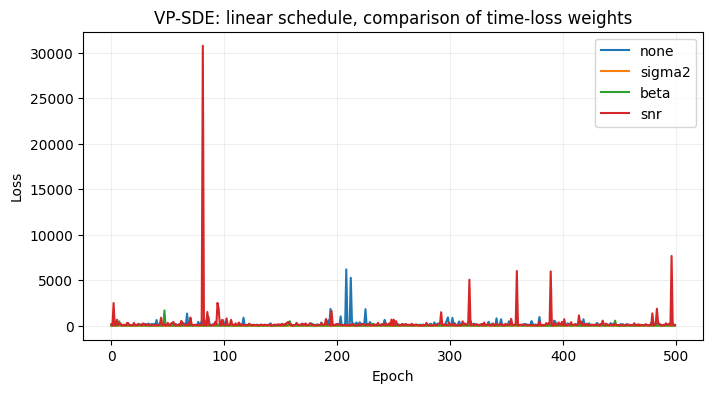

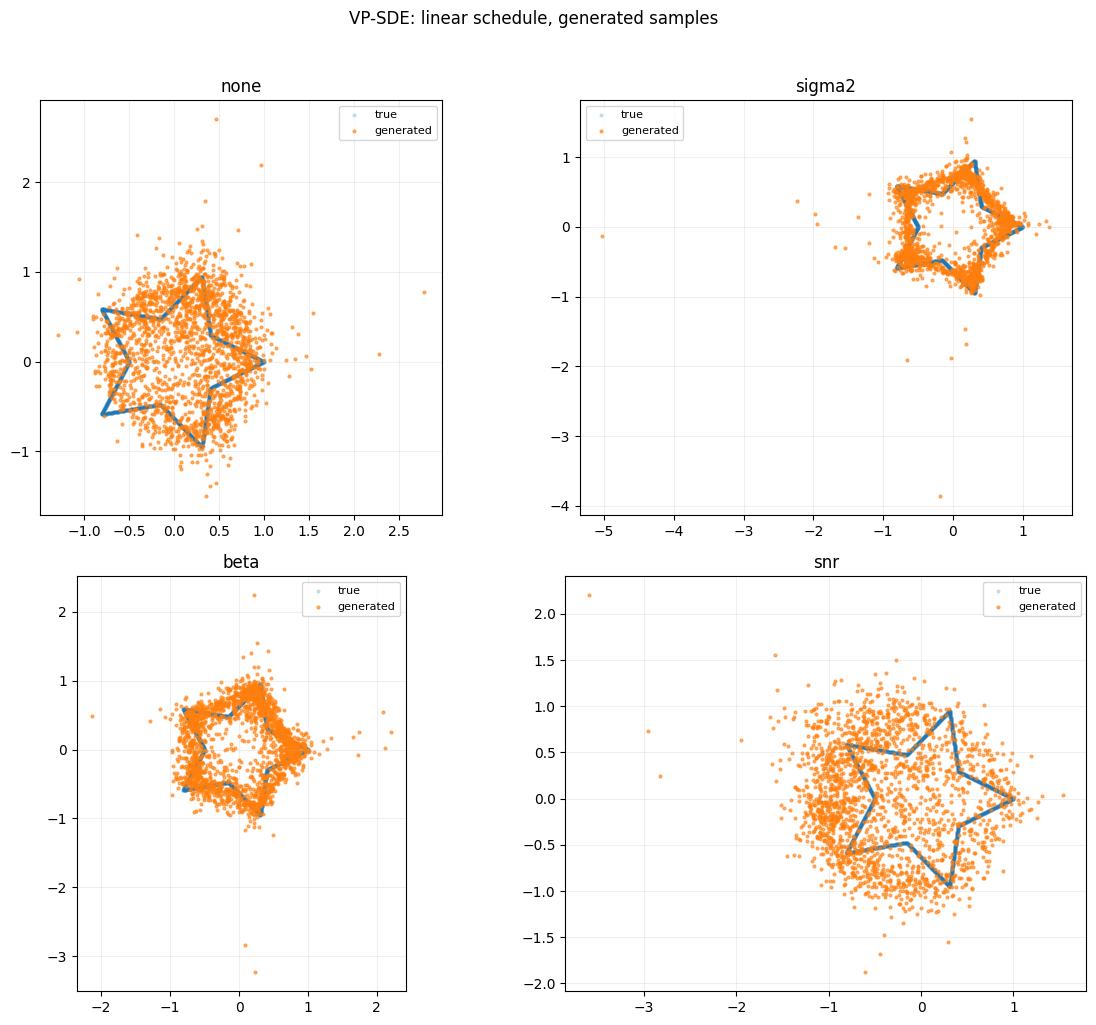

In [27]:
loss_modes = ["none", "sigma2", "beta", "snr"]
weight_histories = {}
weight_samples = {}

for mode in loss_modes:
    trainer = VPSDETrainer(cfg, schedule="linear", loss_weight_mode=mode)
    trainer.train(cfg.epochs_weight)
    weight_histories[mode] = trainer.history
    weight_samples[mode] = trainer.sample(n=2000)

plot_losses(weight_histories, "VP-SDE: linear schedule, comparison of time-loss weights")
plot_samples_grid(weight_samples, data, "VP-SDE: linear schedule, generated samples")

## 6. Сравнение расписаний (лучший weight из прошлого блока)

[linear  | beta        ] epoch   60/300  loss=32.5834
[linear  | beta        ] epoch  120/300  loss=34.8179
[linear  | beta        ] epoch  180/300  loss=14.8798
[linear  | beta        ] epoch  240/300  loss=17.9876
[linear  | beta        ] epoch  300/300  loss=16.9436
[cosine  | beta        ] epoch   60/300  loss=28.7132
[cosine  | beta        ] epoch  120/300  loss=22.7194
[cosine  | beta        ] epoch  180/300  loss=23.3332
[cosine  | beta        ] epoch  240/300  loss=13.8674
[cosine  | beta        ] epoch  300/300  loss=50.5262


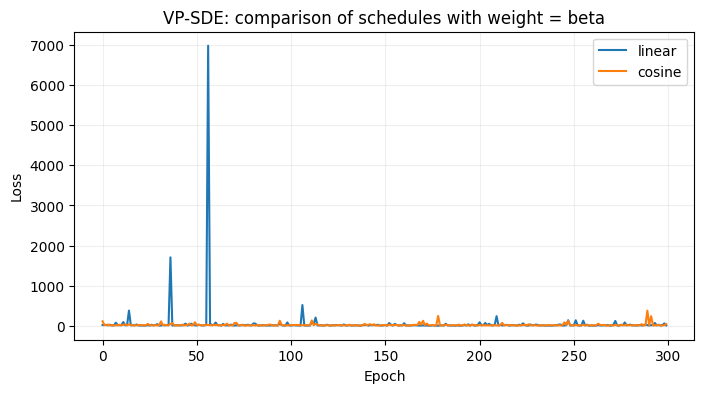

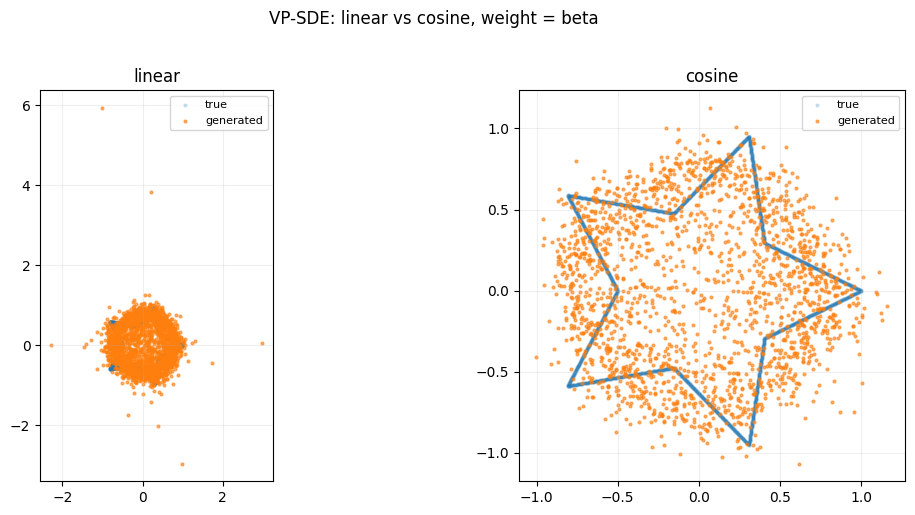

In [23]:
best_weight_mode = "beta"

schedule_histories = {}
schedule_samples = {}

for schedule in ["linear", "cosine"]:
    trainer = VPSDETrainer(cfg, schedule=schedule, loss_weight_mode=best_weight_mode)
    trainer.train(cfg.epochs_schedule)
    schedule_histories[schedule] = trainer.history
    schedule_samples[schedule] = trainer.sample(n=2000)

plot_losses(schedule_histories, f"VP-SDE: comparison of schedules with weight = {best_weight_mode}")
plot_samples_grid(schedule_samples, data, f"VP-SDE: linear vs cosine, weight = {best_weight_mode}")

## 7.  вывод
none ($\lambda = 1$): В непрерывном времени это стандартный Score Matching. Проблема в том, что он уделяет слишком много внимания малым $t$

sigma2 ($\lambda = \sigma^2$):  Он балансирует веса так, что модель уделяет равное внимание всем моментам времени. Звездочка получается относительно  ровной, с хорошим балансом между центром и лучами, но меньше шума в центре относительно других

snr : Смещает фокус на промежуточные шаги

beta ($\lambda = \beta$): Хорошо работает , так как штрафует модель пропорционально дисперсии броуновского движения на текущем шаге, заставляя ее лучше чистить данные на зашумленных этапах.


Linear Schedule: Линейно наращивает $\beta(t)$. На последних шагах диффузии модель работает вслепую поэтому точки "разлетаются" мимо лучей.

Cosine Schedule: Меняет $\beta(t)$ так, чтобы уровень шума нарастал плавно (по функции косинуса). На генерации косинусное расписание дает более четкие, неразмытые контуры звездочки по сравнению с линейным и меньше разброс шума.